Saving bank.csv to bank.csv
   age         job  marital     education  balance housing loan    y
0   30       admin   single      graduate     1200     yes   no  yes
1   42  technician  married    highschool     2500      no  yes   no
2   35    services   single      graduate     1800     yes   no  yes
3   28  management  married  postgraduate     3200     yes   no  yes
4   50     retired  married    highschool     4000      no   no   no
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        10 non-null     int64 
 1   job        10 non-null     object
 2   marital    10 non-null     object
 3   education  10 non-null     object
 4   balance    10 non-null     int64 
 5   housing    10 non-null     object
 6   loan       10 non-null     object
 7   y          10 non-null     object
dtypes: int64(2), object(6)
memory usage: 772.0+ bytes
None
Accurac

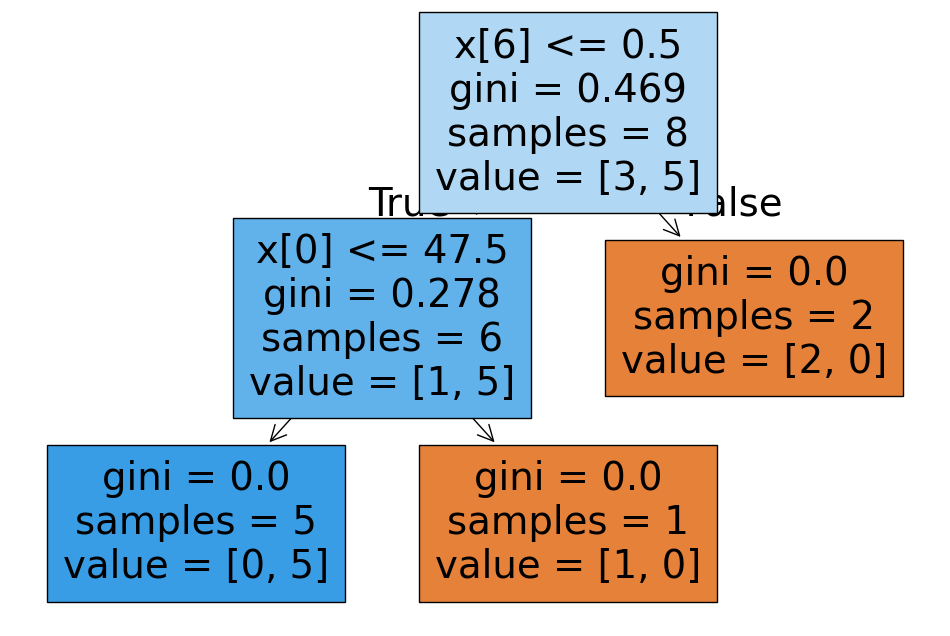

In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Upload dataset
uploaded = files.upload()

# Read dataset
df = pd.read_csv("bank.csv")   # change filename if needed

print(df.head())
print(df.info())

# Convert categorical columns into numbers
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop('y', axis=1)   # target column
y = df['y']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot decision tree
plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()